In [17]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("qtagg")
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tqdm import tqdm
import mne
from matplotlib import cm

from scipy.signal import hilbert
from mne_connectivity.viz import plot_connectivity_circle

In [18]:
id = 'sub-010003'
condition = 'EO'  # or 'EC'
band1 = 'delta'
band2 = 'delta'

In [ ]:
id = 'sub-010003'
condition = 'EO' 

preprocess_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed'
path = os.path.join(preprocess_path, id, f"{id}_{condition}_eeg.fif")

raw = mne.io.read_raw_fif(path, preload=True)
raw.load_data()
raw = raw.copy().pick("eeg")

In [20]:
raw.plot()

In [21]:
from scripts.eeg import connectivity

In [24]:
epoch_duration = 2.0  # Duration of each epoch in seconds

epochs = connectivity.create_epochs(raw, epoch_duration)

d:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\scripts\eeg\connectivity.py:43: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_duration,


In [27]:
epochs.drop_log

((np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD

In [7]:
phase = connectivity.get_phase(epochs)  # shape: (n_channels, n_times)

In [8]:
n_channels, n_times = phase.shape
print( f"Number of channels: {n_channels}, Number of time points: {n_times}")

Number of channels: 61, Number of time points: 5001


In [9]:
# Initialize the phase-phase matrix
n_channels = phase.shape[0]
psi_matrix = np.zeros((n_channels, n_channels))

# Compute n:m phase-phase coupling for each channel pair
for i in tqdm(range(n_channels), desc=f"Computing PSI ({id}, {condition})", leave=True):
    for j in range(n_channels):
        phase_diff = phase[j] - phase[i]
        # Compute PSI for the current m
        psi = np.abs(np.mean(np.exp(1j * phase_diff)))
        psi_matrix[i, j] = psi

psi_matrix = np.array(psi_matrix)

Computing PSI (sub-010002, EO): 100%|██████████| 61/61 [00:01<00:00, 55.37it/s]


In [10]:
plt.figure(figsize=(10, 8))

sns.heatmap(psi_matrix, xticklabels=epochs.ch_names, yticklabels=epochs.ch_names,
        cmap='viridis', center=0, annot=False, fmt=".2f", square=True)
plt.title(f'Phase Synchronization Index ({id}, {condition})')
plt.xlabel('Channel')
plt.ylabel('Channel')
plt.tight_layout()

In [11]:
threshold = 0.8
psi_matrix = np.where(np.abs(psi_matrix) >= threshold, psi_matrix, 0)

In [12]:

n_channels = len(epochs.ch_names)
cmap = cm.get_cmap('tab10', n_channels)
node_colors = [cmap(i) for i in range(n_channels)]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plot_connectivity_circle(
    con=psi_matrix,
    node_names=epochs.ch_names,
    title=f"Phase Synchronisation Index (PSI) Connectivity Circle ({id}, {condition})",
    colormap='coolwarm',
    n_lines=None,
    node_colors=node_colors,
    facecolor='white',
    textcolor='black',
    linewidth=1.5,
    fig=fig,
    ax=ax,
)

C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_51056\475610315.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', n_channels)
d:\FY2025\Fukuyama\Programs\anaconda3\envs\mne\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


(<Figure size 800x800 with 2 Axes>,
 <PolarAxes: title={'center': 'Phase Synchronisation Index (PSI) Connectivity Circle (sub-010002, EO)'}>)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def custom_topomap(data, info, show_sensors=True, names=True, title=None):
    """
    Draw EEG topomap manually without using mne.viz.plot_topomap().
    
    Args:
        data (array-like): Values for each EEG channel (n_channels,).
        info (mne.Info): MNE info object containing channel locations.
        show_sensors (bool): If True, plot electrode locations.
        names (bool): If True, show channel names.
        title (str): Optional title.
    """

    # -----------------------------
    # 1. Get EEG channel locations
    # -----------------------------
    montage = info.get_montage()
    pos = montage.get_positions()['ch_pos']
    ch_names = info.ch_names

    xy = np.array([pos[ch][:2] for ch in ch_names])  # take only x, y (ignore z)
    x, y = xy[:, 0], xy[:, 1]

    # -----------------------------
    # 2. Interpolate data values
    # -----------------------------
    grid_x, grid_y = np.mgrid[
        x.min()-0.05:x.max()+0.05:100j,
        y.min()-0.05:y.max()+0.05:100j
    ]

    # Interpolate using cubic method
    grid_z = griddata(
        points=np.c_[x, y],
        values=data,
        xi=(grid_x, grid_y),
        method='cubic',
        fill_value=np.nan
    )

    # Mask out points outside the head circle
    r = 0.5  # roughly radius of the head
    mask = (grid_x**2 + grid_y**2) > (r**2)
    grid_z[mask] = np.nan

    # -----------------------------
    # 3. Plot head outline + data
    # -----------------------------
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(
        grid_z.T,
        extent=(x.min(), x.max(), y.min(), y.max()),
        origin='lower',
        cmap='RdBu_r'
    )
    plt.colorbar(im, ax=ax, shrink=0.8, label='Value')

    # Head outline
    circle = plt.Circle((0, 0), r, color='k', fill=False, lw=1.5)
    ax.add_artist(circle)

    # Optional: sensors
    if show_sensors:
        ax.scatter(x, y, c='k', s=25, zorder=10)
    if names:
        for i, name in enumerate(ch_names):
            ax.text(x[i], y[i], name, fontsize=8, ha='center', va='center')

    ax.set_aspect('equal')
    ax.set_xlim(-r*1.1, r*1.1)
    ax.set_ylim(-r*1.1, r*1.1)
    ax.axis('off')
    if title:
        ax.set_title(title)

    plt.show()


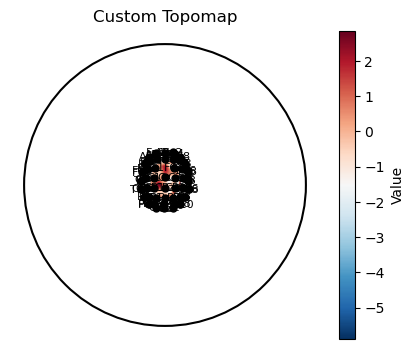

In [31]:
data = np.random.randn(len(epochs.ch_names))  # 仮のチャネル値
custom_topomap(data, epochs.info, title='Custom Topomap')

In [28]:
# data: ダミーでもOK（ゼロの配列）
data = np.zeros(len(epochs.ch_names))

# 図と軸の用意
fig, ax = plt.subplots(figsize=(8, 8))

#トポマップを描画（実質、頭皮マップの土台）
mne.viz.plot_topomap(
    data,
    epochs.info,
    axes=ax,
    show=False,
    names=epochs.ch_names,
    sensors=True
)

# チャンネル位置を取得（2D投影座標）
layout = mne.find_layout(epochs.info)
pos = layout.pos[:, :2]  # shape: (n_channels, 2)
pos = pos * [fig.get_figwidth(), fig.get_figheight()]  # スケール合わせ

# PSIの閾値でつながりを抽出（0以上）
threshold = 0.8
n_channels = len(epochs.ch_names)

for i in range(n_channels):
    for j in range(i + 1, n_channels):
        if psi_matrix[i, j] > threshold:
            x = [pos[i, 0], pos[j, 0]]
            y = [pos[i, 1], pos[j, 1]]
            ax.plot(x, y, color='red', linewidth=1.5, alpha=0.7)

# 黒丸で電極を描画
for x, y in pos:
    ax.plot(x, y, 'ko', markersize=5)

ax.set_title("PSI-based Connectivity")
plt.tight_layout()
plt.show()


NameError: name 'psi_matrix' is not defined

In [172]:
# 10-10システムのモンタージュを読み込み
montage = mne.channels.make_standard_montage("standard_1020")

# モンタージュをepochsに適用（FCzをリファレンスとして再設定した後でも適用可）
epochs.set_montage(montage)

# FCz をリファレンスに再設定
epochs.set_eeg_reference(ref_channels=["Fz"])

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


<Epochs | 1 events (all good), 0 – 2 s (baseline off), ~2.4 MiB, data loaded,
 '1': 1>

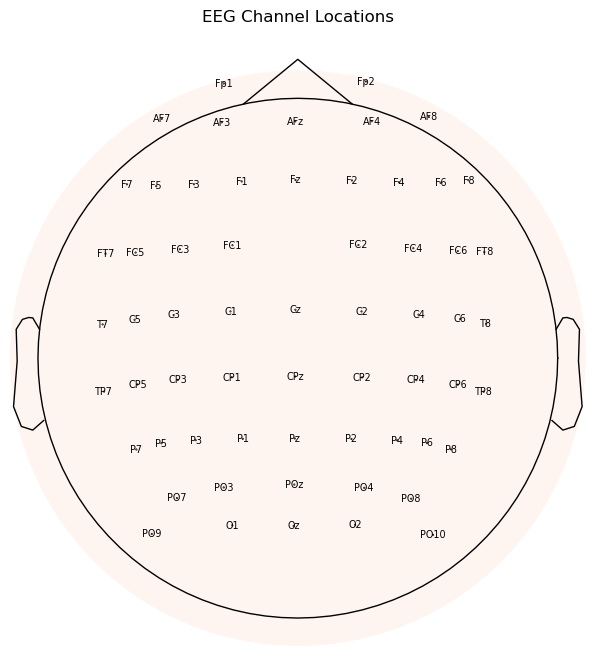

In [ ]:
# すべてのチャネルにゼロ値を割り当てる
data = np.zeros(len(epochs.ch_names))

fig, ax = plt.subplots(figsize=(8, 8))

mne.viz.plot_topomap(
    data,
    epochs.info,      # infoオブジェクトをpos引数に渡せば位置情報として使われる
    axes=ax,
    show=False,
    names=epochs.ch_names,
    sensors=True
)

ax.set_title('EEG Channel Locations')
plt.show()

In [ ]:
from mne_connectivity.viz import plot_sensors_connectivity
import matplotlib
matplotlib.use('Agg')
n_lines = 20  # 表示する接続の本数

plot_sensors_connectivity(
    info=epochs.info,
    con=psi_matrix,
)


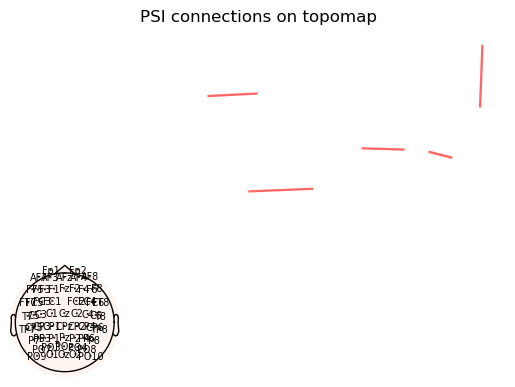

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# PSIしきい値（0以上）
threshold = 0.

# チャネル位置取得（2D座標）
layout = mne.channels.make_eeg_layout(epochs.info)
pos = layout.pos[:, :2]  # shape: (n_channels, 2)

# PSI値とチャネル数
n_channels = len(epochs.ch_names)
assert psi_matrix.shape == (n_channels, n_channels)

# ダミーdata（plot_topomap用）
data = np.zeros(n_channels)

# 頭皮マップ描画
fig, ax = plt.subplots(figsize=(8, 8))
mne.viz.plot_topomap(
    data,
    epochs.info,
    axes=ax,
    show=False,
    names=epochs.ch_names,
    sensors=True,
)

# PSIに基づく線の描画
for i in range(n_channels):
    for j in range(i + 1, n_channels):
        psi_val = psi_matrix[i, j]
        if psi_val > threshold:
            x_coords = [pos[i, 0], pos[j, 0]]
            y_coords = [pos[i, 1], pos[j, 1]]
            ax.plot(x_coords, y_coords, color='red', alpha=0.6, linewidth=2 * psi_val)

plt.title("PSI > 0 connections on topomap")
plt.show()


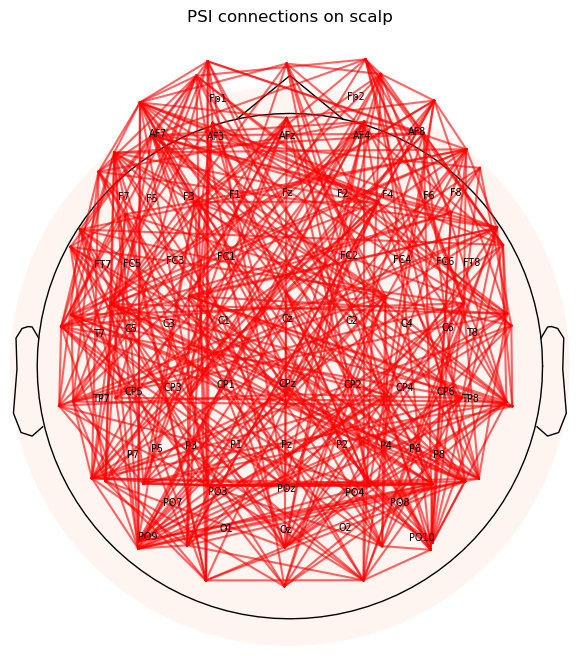

In [195]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# ① 空データでトポマップ（2D頭皮）を表示
data = np.zeros(len(epochs.ch_names))
fig, ax = plt.subplots(figsize=(8, 8))
mne.viz.plot_topomap(
    data,
    epochs.info,
    axes=ax,
    show=False,
    names=epochs.ch_names,
    sensors=True
)

# ② センサ位置を取得（2D）
pos = np.array([epochs.info['chs'][epochs.ch_names.index(ch)]['loc'][:2] for ch in epochs.ch_names])

# ③ PSI行列としきい値（0以上）で結合を線で描画
threshold = 0.8
n_channels = len(epochs.ch_names)

for i in range(n_channels):
    for j in range(i + 1, n_channels):
        psi_value = psi_matrix[i, j]
        if psi_value >= threshold:
            x_coords = [pos[i, 0], pos[j, 0]]
            y_coords = [pos[i, 1], pos[j, 1]]
            ax.plot(x_coords, y_coords, color='red', alpha=0.6, linewidth=1.5)

plt.title("PSI connections on scalp")
plt.show()


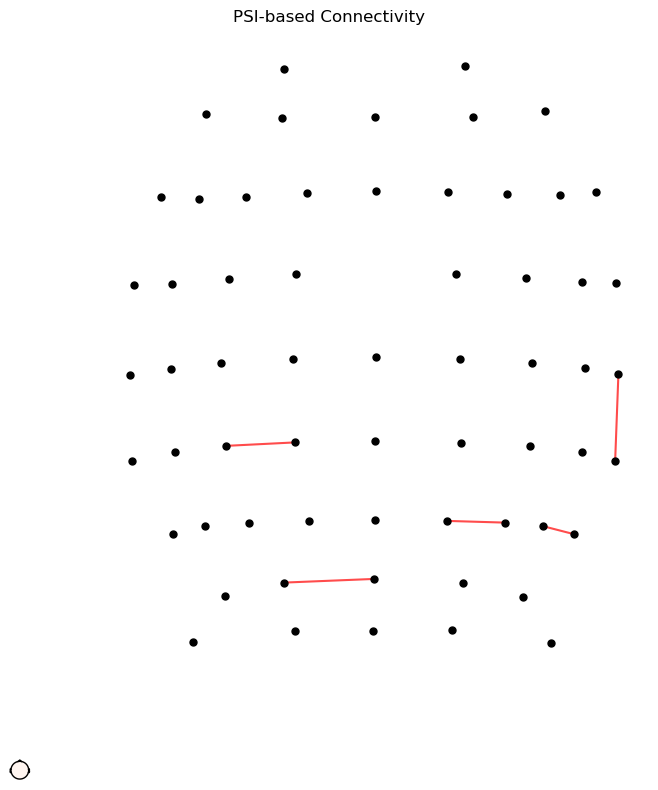

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# data: ダミーでもOK（ゼロの配列）
data = np.zeros(len(epochs.ch_names))

# 図と軸の用意
fig, ax = plt.subplots(figsize=(8, 8))

# トポマップを描画（実質、頭皮マップの土台）
mne.viz.plot_topomap(
    data,
    epochs.info,
    axes=ax,
    show=False,
    names=epochs.ch_names,
    sensors=True
)

# チャンネル位置を取得（2D投影座標）
layout = mne.find_layout(epochs.info)
pos = layout.pos[:, :2]  # shape: (n_channels, 2)
pos = pos * [fig.get_figwidth(), fig.get_figheight()]  # スケール合わせ

# PSIの閾値でつながりを抽出（0以上）
threshold = 0.8
n_channels = len(epochs.ch_names)

for i in range(n_channels):
    for j in range(i + 1, n_channels):
        if psi_matrix[i, j] > threshold:
            x = [pos[i, 0], pos[j, 0]]
            y = [pos[i, 1], pos[j, 1]]
            ax.plot(x, y, color='red', linewidth=1.5, alpha=0.7)

# 黒丸で電極を描画
for x, y in pos:
    ax.plot(x, y, 'ko', markersize=5)

ax.set_title("PSI-based Connectivity")
plt.tight_layout()
plt.show()


In [201]:
import numpy as np
import matplotlib.pyplot as plt
from mne.viz import plot_sensors

def topoplot_connect(info, con_matrix, threshold=0.5):
    """
    Plot a topographic connectivity graph over EEG sensor positions.

    Parameters:
        info (mne.Info): The info object from raw or epochs containing channel location.
        con_matrix (ndarray): 2D square connectivity matrix (n_channels x n_channels).
        threshold (float): Minimum absolute connection strength to be visualized.
    """

    # Get channel locations (2D projections)
    pos = np.array([info['chs'][i]['loc'][:2] for i in range(len(info['chs']))])
    ch_names = [info['ch_names'][i] for i in range(len(info['chs']))]

    # Normalize positions to [0, 1] range for plotting
    pos -= pos.min(axis=0)
    pos /= pos.max(axis=0)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_aspect('equal')

    # Plot the head outline (optional: you can draw a circle)
    circle = plt.Circle((0.5, 0.5), 0.5, color='k', fill=False, linewidth=2)
    ax.add_artist(circle)

    # Plot the sensors
    ax.scatter(pos[:, 0], pos[:, 1], s=30, color='k', zorder=3)

    # Plot connectivity
    n_channels = con_matrix.shape[0]
    for i in range(n_channels):
        for j in range(i+1, n_channels):
            strength = con_matrix[i, j]
            if np.abs(strength) >= threshold:
                x = [pos[i, 0], pos[j, 0]]
                y = [pos[i, 1], pos[j, 1]]
                color = 'r' if strength > 0 else 'b'
                ax.plot(x, y, color=color, linewidth=np.abs(strength)*2, alpha=0.7, zorder=2)

    # Add channel names
    for i, name in enumerate(ch_names):
        ax.text(pos[i, 0], pos[i, 1]+0.02, name, fontsize=6, ha='center')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title('Topographic Connectivity')
    plt.tight_layout()
    plt.show()



Opening raw data file D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\preprocessed\sub-010002\sub-010002_EO_eeg.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Range : 171871 ... 1331887 =     68.748 ...   532.755 secs
Ready.
Reading 0 ... 1160016  =      0.000 ...   464.006 secs...


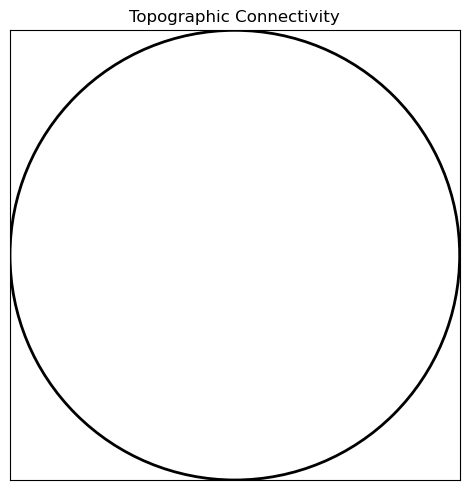

In [202]:
preprocess_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed'
path = os.path.join(preprocess_path, id, f"{id}_{condition}_eeg.fif")

raw = mne.io.read_raw_fif(path, preload=True)
raw.load_data()

con_matrix = np.random.rand(n_channels, n_channels)

con_matrix = np.random.rand(len(raw.ch_names), len(raw.ch_names))
np.fill_diagonal(con_matrix, 0)  # 対角要素はゼロに
topoplot_connect(raw.info, con_matrix, threshold=0.6)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# ダミーデータ（全0）
data = np.zeros(len(epochs.ch_names))

# PSIマトリクスとしきい値
psi_matrix = np.random.rand(len(epochs.ch_names), len(epochs.ch_names))  # 例
threshold = 0.8

# センサ位置
pos = mne.channels.make_1020_channel_selections(epochs.info)[0]['positions']
pos = np.array([epochs.info['chs'][epochs.ch_names.index(ch)]['loc'][:2] for ch in epochs.ch_names])

# プロット開始
fig, ax = plt.subplots(figsize=(8, 8))

# トポマッププロット（カラーマップなし、センサー名・マーカー表示）
mne.viz.plot_topomap(
    data,
    epochs.info,
    axes=ax,
    show=False,
    sensors=True,
    names=epochs.ch_names,
    show_names=False,
    contours=0,
    image_interp='bilinear',
    vmin=0, vmax=0  # 値は全部0
)

# センサ位置に黒丸マーカー
ax.scatter(pos[:, 0], pos[:, 1], c='black', s=30, zorder=3)

# PSIのしきい値に従って線を描画
for i in range(len(epochs.ch_names)):
    for j in range(i + 1, len(epochs.ch_names)):
        if psi_matrix[i, j] > threshold:
            x = [pos[i, 0], pos[j, 0]]
            y = [pos[i, 1], pos[j, 1]]
            ax.plot(x, y, color='red', alpha=0.6, linewidth=1.5)

# 軸の調整
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


KeyError: 0

In [180]:
import mne
import os
import numpy as np
from mne import make_fixed_length_events

from mne_connectivity import phase_slope_index
from mne_connectivity.viz import plot_connectivity_circle
import matplotlib.pyplot as plt
import matplotlib.cm as cm


In [4]:
eo_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed\\sub-010002\\sub-010002_EO.fif'
ec_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed\\sub-010002\\sub-010002_EC.fif'

In [5]:
# Define analysis parameters
freqs = np.arange(6, 30, 2)         # Frequency range: 6 to 28 Hz
n_cycles = freqs / 2                # Number of cycles per frequency
epoch_duration = 2.0                # Epoch length in seconds
epoch_i = 0                         # Epoch index for visualization
ch_i = 0                            # Channel index for visualization

In [6]:
raw_ec = mne.io.read_raw_fif(ec_path, preload=True)
raw_eo = mne.io.read_raw_fif(eo_path, preload=True)

Opening raw data file D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\preprocessed\sub-010002\sub-010002_EC.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Range : 15962 ... 1175978 =      6.385 ...   470.391 secs
Ready.


C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_36160\3000859238.py:1: RuntimeWarning: This filename (D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\preprocessed\sub-010002\sub-010002_EC.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_ec = mne.io.read_raw_fif(ec_path, preload=True)


Reading 0 ... 1160016  =      0.000 ...   464.006 secs...
Opening raw data file D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\preprocessed\sub-010002\sub-010002_EO.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Range : 171871 ... 1331887 =     68.748 ...   532.755 secs
Ready.
Reading 0 ... 1160016  =      0.000 ...   464.006 secs...


C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_36160\3000859238.py:2: RuntimeWarning: This filename (D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\preprocessed\sub-010002\sub-010002_EO.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_eo = mne.io.read_raw_fif(eo_path, preload=True)


In [7]:
def create_epochs(raw, epoch_duration):
    """
    Create epochs from raw data with fixed-length events.
    
    Args:
        raw (mne.io.Raw): Raw EEG data.
        epoch_duration (float): Duration of each epoch in seconds.
        
    Returns:
        mne.Epochs: Epochs created from the raw data.
    """
    # Check if the raw data is already preloaded
    if not raw.preload:
        raw.load_data()
    
    # Create fixed-length events
    events = mne.make_fixed_length_events(raw, id=1, duration=epoch_duration)
    
    # Create epochs
    epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_duration,
                        baseline=None, preload=True)
    
    return epochs

In [8]:
# Epoching
epochs_ec = create_epochs(raw_ec, epoch_duration)
epochs_eo = create_epochs(raw_eo, epoch_duration)

Not setting metadata
232 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 232 events and 5001 original time points ...
231 bad epochs dropped
Not setting metadata
232 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 232 events and 5001 original time points ...
231 bad epochs dropped


In [ ]:
def plot_psi_connectivity_circle(epochs):
    """
    Compute and visualize Phase Slope Index (PSI) connectivity in a circular graph.

    Args:
        epochs (mne.Epochs): Preprocessed epochs data.
    """
    # Step 1: Prepare
    data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
    sfreq = epochs.info["sfreq"]
    ch_names = epochs.ch_names
    n_channels = len(ch_names)

    # Step 2: Create connection indices (excluding self-connections)
    indices = tuple(zip(*[(i, j) for i in range(n_channels) for j in range(n_channels) if i != j]))

    # Step 3: Compute PSI
    psi = phase_slope_index(
        data=data,
        sfreq=sfreq,
        mode="multitaper",
        fmin=10.0,
        fmax=20.0,
        indices=indices,
        tmin=0.0,
        n_jobs=1,
    )

    freqs = psi.freqs
    freq_idx = np.argmin(np.abs(freqs - 10))  # Closest to 10Hz
    psi_data = psi.get_data()  # (n_connections, n_freqs)
    psi_at_10hz = psi_data[:, freq_idx]

    # Step 4: Convert to square matrix
    con_matrix = np.zeros((n_channels, n_channels))
    for (i, j), value in zip(zip(*psi.indices), psi_at_10hz):
        con_matrix[i, j] = value

    # Step 5: Threshold for visualization
    threshold = 0.3
    con_matrix_thresh = np.copy(con_matrix)
    con_matrix_thresh[con_matrix_thresh < threshold] = 0

    # Step 6: Visualization - circular plot
    cmap = cm.get_cmap('tab10', n_channels)
    node_colors = [cmap(i) for i in range(n_channels)]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plot_connectivity_circle(
        con=con_matrix_thresh,
        node_names=ch_names,
        title="Phase Slope Index (PSI) at ~10Hz",
        colormap='coolwarm',
        n_lines=None,
        node_colors=node_colors,
        facecolor='white',
        textcolor='black',
        linewidth=1.5,
        fig=fig,
        ax=ax,
    )
    plt.show()

    # Step 7: Matrix heatmap
    plt.figure(figsize=(6, 5))
    plt.imshow(con_matrix, vmin=0, vmax=1, cmap='hot')
    plt.title(f"PSI Matrix @ {freqs[freq_idx]:.1f} Hz")
    plt.xlabel("Channel")
    plt.ylabel("Channel")
    plt.colorbar(label="PSI")
    plt.tight_layout()
    plt.show()



In [18]:
plot_psi_connectivity_circle(epochs_ec)
_ = plot_psi_connectivity_circle(epochs_eo)

Estimating phase slope index (PSI)
Connectivity computation...
    computing connectivity for 3782 connections
    using t=0.000s..2.000s for estimation (5001 points)
    frequencies: 10.5Hz..20.0Hz (20 points)
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherency
    computing cross-spectral density for epoch 1
[Connectivity computation done]
Computing PSI from estimated Coherency: <SpectralConnectivity | freq : [10.497900, 19.996001], , nave : 1, nodes, n_estimated : 62, 3782, ~1.4 MiB>
[PSI Estimation Done]


TypeError: unsupported operand type(s) for -: 'list' and 'int'

In [39]:
n =  1  # Phase frequency multiplier
m = 1  # Amplitude frequency multiplier

bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'low_gamma': (30, 50),
    'mid_gamma': (50, 80),
    'high_gamma': (80, 100)
}

In [64]:
def estimate_m_range(phase1_band, phase2_band):
    """
    Estimate the range of m such that m * phase1_freq approximates phase2_freq.
    Inputs are tuples representing frequency bands, e.g., (0.5, 4) for delta.
    Returns integer m_min and m_max.
    """
    f1_min, f1_max = phase1_band
    f2_min, f2_max = phase2_band

    # Avoid division by zero
    if f1_max == 0 or f1_min == 0:
        raise ValueError("Frequency band includes 0 Hz, which is invalid.")

    m_min = round(np.floor(f2_min / f1_max))  # e.g. phase1 maxが4Hz, phase2 minが4Hzなら m_min = 1
    m_max = round(np.ceil(f2_max / f1_min))   # e.g. phase1 minが0.5Hz, phase2 maxが8Hzなら m_max = 16

    # Ensure m_min is at least 1
    m_min = max(1, m_min)

    return m_min, m_max


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
delta_phase = m * phase2[j] - n * phase1[i]
plv_nm = np.abs(np.mean(np.exp(1j * delta_phase)))

In [65]:
def find_best_m_for_n1(phase1, phase2, m_range=(1, 10), plot=True):
    """
    Find the best m value for fixed n=1 that maximizes phase-locking value (PLV)
    
    Parameters:
        phase1 (ndarray): Phase time series of the low-frequency signal
        phase2 (ndarray): Phase time series of the high-frequency signal
        m_range (tuple): Range of m values to test (min, max), inclusive
    
    Returns:
        best_m (int): Value of m with highest PLV for n=1
        psi_values (ndarray): PSI values for each m in the given range
    """
    n = 1
    #m_vals = np.arange(m_range[0], m_range[1] + 0.1, 0.1)
    m_vals = np.arange(m_range[0], m_range[1] + 1, 1)
    psi_values = []

    for m in m_vals:
        # Compute phase difference for n=1:m
        phase_diff = n * phase2 - m * phase1
        # Compute PSI for the current m
        psi = np.abs(np.mean(np.exp(1j * phase_diff)))
        psi_values.append(psi)

    psi_values = np.array(psi_values)
    best_psi = np.argmax(psi_values)
    best_m = m_vals[best_psi]

    # Plot the results
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(m_vals, psi_values, marker='o')
        plt.title('Phase Slope Index (PSI) for n=1 and varying m')
        plt.xlabel('m (harmonic of wave)')
        plt.ylabel('Phase Slope Index (PSI)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return best_m, best_psi


In [ ]:
import numpy as np
from mne.time_frequency import tfr_array_morlet
from scipy.signal import hilbert

def get_phase(raw1, raw2, f1, f2, method='hilbert'):
    """    Extract phase information from two raw EEG datasets using either Hilbert transform or wavelet transform. 
    Parameters:
        raw1 (mne.io.Raw): First raw EEG dataset.
        raw2 (mne.io.Raw): Second raw EEG dataset.
        f1 (tuple): Frequency band for the first dataset (e.g., theta).
        f2 (tuple): Frequency band for the second dataset (e.g., alpha).
        method (str): Method to use for phase extraction ('hilbert' or 'wavelet').
    Returns:
        phase1 (ndarray): Phase of the first dataset, shape: (n_channels, n_times).
        phase2 (ndarray): Phase of the second dataset, shape: (n_channels, n_times).
    """

    if method == 'hilbert':
        phase1 = np.angle(hilbert(raw1.get_data(), axis=1))  # shape: (n_channels, n_times)
        phase2 = np.angle(hilbert(raw2.get_data(), axis=1))
    elif method == 'wavelet':
        #freqs1 = np.linspace(f1[0], f1[1], 2)
        #freqs2 = np.linspace(f2[0], f2[1], 2)
        freqs1 = np.arange(f1[0], f1[1], 2)
        freqs2 = np.arange(f2[0], f2[1], 2)

        epochs1 = create_epochs(raw1, epoch_duration)
        epochs2 = create_epochs(raw2, epoch_duration)
        
        # Phase1 extraction
        phase1 = tfr_array_morlet(epochs1, sfreq=raw1.info['sfreq'],
                                  freqs=freqs1, n_cycles=freqs1 / 2, output='phase')[0]
        phase1 = np.mean(phase1, axis=1)  # shape: (n_channels, n_times)

        # Phase2 extraction
        phase2 = tfr_array_morlet(epochs2, sfreq=raw2.info['sfreq'],
                                  freqs=freqs2, n_cycles=freqs1 / 2, output='phase')[0]
        phase2 = np.mean(phase2, axis=1)
    else:
        raise ValueError("method must be 'hilbert' or 'wavelet'")
    
    return phase1, phase2

In [ ]:
freqs2 = np.linspace(0.5, 4, )
print(freqs2)

[0.5        0.88888889 1.27777778 1.66666667 2.05555556 2.44444444
 2.83333333 3.22222222 3.61111111 4.        ]


In [73]:
def compute_nm_phase_phase_matrix(raw, band1, band2, method='wavele'):
    """
    Compute n:m phase-phase coupling between all pairs of EEG channels.

    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data (preprocessed).
    band1 : str
        Name of the first frequency band (e.g., 'delta').
    band2 : str
        Name of the second frequency band (e.g., 'delta').
    method : str
        'hilbert' or 'wavelet'
    plot : bool
        Whether to display a heatmap of the resulting matrix.

    Returns:
    --------
    phase_phase_matrix : np.ndarray, shape (n_channels, n_channels)
        Matrix of n:m phase-phase coupling values (PSI).
    """

    bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'low_gamma': (30, 50),
    'mid_gamma': (50, 80),
    'high_gamma': (80, 100)
    }

    # Bandpass filtering
    f1 = bands[band1]
    f2 = bands[band2]
    raw1 = raw.copy().filter(f1[0], f1[1], method='iir', verbose=False)
    raw2 = raw.copy().filter(f2[0], f2[1], method='iir', verbose=False)

    # Get phase information
    phase1, phase2 = get_phase(raw1, raw2, f1, f2, method=method)
    print(phase1.shape, phase2.shape)

    # Initialize the phase-phase matrix
    n_channels = phase1.shape[0]
    psi_matrix = np.zeros((n_channels, n_channels))

    m_min, m_max = estimate_m_range(f1, f2)

    # Compute n:m phase-phase coupling for each channel pair
    for i in range(n_channels):
        for j in range(n_channels):
            best_m, best_psi = find_best_m_for_n1(phase1[i], phase2[j], m_range=(m_min, m_max))
            psi_matrix[i, j] = best_psi

    # Save the matrix to a file
    #save_psi_matrix(psi_matrix, id, condition, args.psi_path)

   # plot_save_psi_matrix(psi_matrix, id, condition, best_m, f1, f2, args.psi_path)

    
    return psi_matrix


In [ ]:
band1 = 'delta'  # Example band for phase1
band2 = 'theta'  # Example band for phase2

# Define frequency bands 
raw1 = raw_ecc.copy().filter(0.5, 4, method='iir', verbose=False)  # Delta band
raw2 = raw_ec.copy().filter(4, 8, method='iir', verbose=False)  # Theta band

bands = {
'delta': (0.5, 4),
'theta': (4, 8),
'alpha': (8, 13),
'beta': (13, 30),
'low_gamma': (30, 50),
'mid_gamma': (50, 80),
'high_gamma': (80, 100)
}

# Bandpass filtering
f1 = bands[band1]
f2 = bands[band2]


# Get phase information
phase1, phase2 = get_phase(raw1, raw2, f1, f2, method=''wavelet')
print(phase1.shape, phase2.shape)

In [ ]:
ch_names = epochs.ch_names
n_channels = len(ch_names)

# Step 5: Threshold for visualization
threshold = 0.3
con_matrix_thresh = np.copy(con_matrix)
con_matrix_thresh[con_matrix_thresh < threshold] = 0

# Step 6: Visualization - circular plot
cmap = cm.get_cmap('tab10', n_channels)
node_colors = [cmap(i) for i in range(n_channels)]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plot_connectivity_circle(
    con=con_matrix_thresh,
    node_names=ch_names,
    title="Phase Slope Index (PSI) at ~10Hz",
    colormap='coolwarm',
    n_lines=None,
    node_colors=node_colors,
    facecolor='white',
    textcolor='black',
    linewidth=1.5,
    fig=fig,
    ax=ax,
)
plt.show()